## Imports

### Install packages

In [4]:
if False:
    !sudo /bin/bash -c "(source /venv/bin/activate; pip install --quiet jupyterlab-vim)"
    !jupyter labextension enable

### Import modules

In [5]:
%load_ext autoreload
%autoreload 2

import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from ipywidgets import interact, FloatSlider, IntSlider, widgets
from IPython.display import display, Markdown

# Set plotting style.
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [31]:
import msml610_utils as ut
import utils_Lesson94_Information_Theory as utils

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

# Setting notebook style
# Notebook signature
Python 3.12.3
Linux 18d0e03c26ae 6.10.14-linuxkit #1 SMP Tue Apr 15 16:00:54 UTC 2025 aarch64 aarch64 aarch64 GNU/Linux
numpy version=1.26.4
pymc version=5.18.2
matplotlib version=3.10.3
arviz version=0.21.0
preliz version=0.19.0


# Entropy and Uncertainty

**Entropy** $H(X)$ of a discrete random variable $X$ is defined as:

$$H(X) = -\sum_x p(x) \log_2 p(x)$$

- Entropy quantifies the average level of **information**, **surprise**, or **uncertainty** inherent in the variable's possible outcomes
- High entropy = more unpredictability
- Low entropy = more certainty

In [32]:
# Test with fair coin.
# Two equally likely outcomes → maximum uncertainty, $H = 1$ bit.
fair_coin = [0.5, 0.5]
print(f"Fair coin entropy: {utils.calculate_entropy(fair_coin):.4f} bits")

Fair coin entropy: 1.0000 bits


In [33]:
# Test with biased coin.
# If heads occurs 90% of the time → less uncertainty, $H < 1$ bit.
biased_coin = [0.9, 0.1]
print(f"Biased coin (90-10) entropy: {utils.calculate_entropy(biased_coin):.4f} bits")

Biased coin (90-10) entropy: 0.4690 bits


In [34]:
# Test with broken coin.
biased_coin = [1.0, 0.0]
print(f"Biased coin (100-0) entropy: {utils.calculate_entropy(biased_coin):.4f} bits")
# If heads occurs 100% of the time → no uncertainty, $H = 0$ bit.

Biased coin (100-0) entropy: -0.0000 bits


## Entropy vs Variance

Entropy and variance are related but measure different properties:
- **Variance** measures how far values are from the mean
- **Entropy** measures how unpredictable a random draw is

A distribution can have high variance but low entropy, or vice versa.

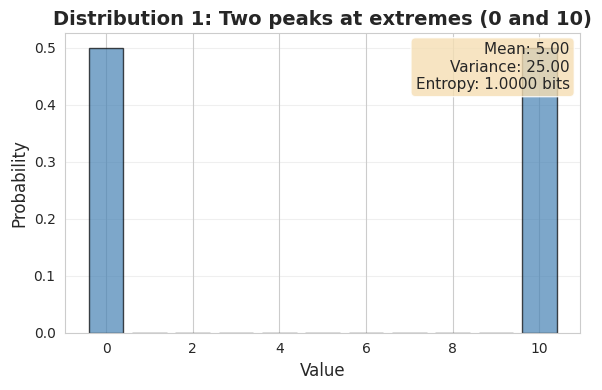

In [40]:
# Compare two distributions with same variance but different entropy.
# Distribution 1: Bimodal with peaks at extremes.
dist1_values = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
dist1_probs = np.array([0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5])

utils.plot_distribution_with_stats(
    values=dist1_values,
    probabilities=dist1_probs,
    title="Distribution 1: Two peaks at extremes (0 and 10)",
)
# This distribution has high variance (spread) but low entropy (only 1 bit).

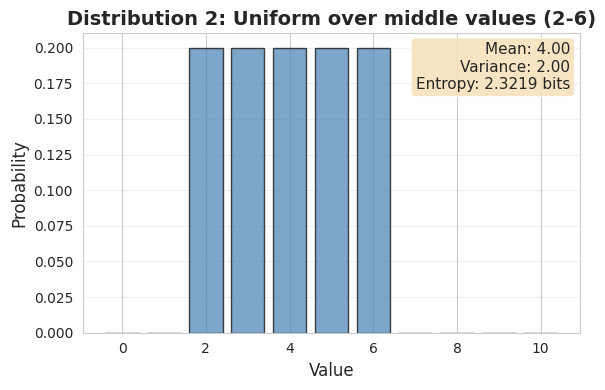

In [41]:
# Distribution 2: Uniform over middle values.
dist2_probs = np.array([0.0, 0.0, 0.2, 0.2, 0.2, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0])

utils.plot_distribution_with_stats(
    values=dist1_values,
    probabilities=dist2_probs,
    title="Distribution 2: Uniform over middle values (2-6)",
)
# This distribution has lower variance but higher entropy (~2.32 bits).

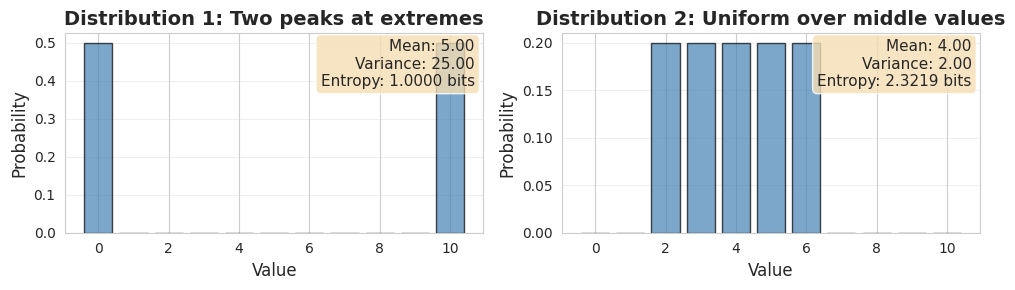


Key insight: Distribution 1 has higher variance but lower entropy.


In [42]:
# Compare the two distributions side by side.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

utils.plot_distribution_with_stats(
    values=dist1_values,
    probabilities=dist1_probs,
    title="Distribution 1: Two peaks at extremes",
    ax=ax1,
)

utils.plot_distribution_with_stats(
    values=dist1_values,
    probabilities=dist2_probs,
    title="Distribution 2: Uniform over middle values",
    ax=ax2,
)

plt.tight_layout()
plt.show()

# Variance measures spread from mean; entropy measures unpredictability.
# Key insight: Distribution 1 has higher variance but lower entropy.

## Entropy and Distribution Spread

Generally, more spread in a distribution leads to higher entropy, but there are exceptions:
- Increasing the support of a uniform distribution increases variance but not entropy
- The relationship depends on the shape of the distribution

In [43]:
# Example: Uniform distributions with different support.
# Uniform over 2 values.
uniform_2 = np.array([0.5, 0.5])
values_2 = np.array([0, 1])

utils.plot_distribution_with_stats(
    values=values_2,
    probabilities=uniform_2,
    title="Uniform distribution over 2 values",
)
# A uniform distribution over 2 outcomes has 1 bit of entropy.

Uniform distribution over 2 values:
  Probabilities: [0.5 0.5]
  Entropy: 1.0000 bits


In [45]:
# Uniform over 4 values.
uniform_4 = np.array([0.25, 0.25, 0.25, 0.25])
values_4 = np.array([0, 1, 2, 3])

utils.plot_distribution_with_stats(
    values=values_4,
    probabilities=uniform_4,
    title="Uniform distribution over 4 values",
)
# A uniform distribution over 4 outcomes has 2 bits of entropy.

Uniform distribution over 4 values:
  Probabilities: [0.25 0.25 0.25 0.25]
  Entropy: 2.0000 bits


In [44]:
# Uniform over 8 values.
uniform_8 = np.array([0.125] * 8)
values_8 = np.array([0, 1, 2, 3, 4, 5, 6, 7])

utils.plot_distribution_with_stats(
    values=values_8,
    probabilities=uniform_8,
    title="Uniform distribution over 8 values",
)
# A uniform distribution over 8 outcomes has 3 bits of entropy.

Uniform distribution over 8 values:
  Probabilities: [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
  Entropy: 3.0000 bits


In [46]:
# Compare uniform distributions with increasing support.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 3))

utils.plot_distribution_with_stats(
    values=values_2,
    probabilities=uniform_2,
    title="Uniform: 2 values",
    ax=ax1,
)

utils.plot_distribution_with_stats(
    values=values_4,
    probabilities=uniform_4,
    title="Uniform: 4 values",
    ax=ax2,
)

utils.plot_distribution_with_stats(
    values=values_8,
    probabilities=uniform_8,
    title="Uniform: 8 values",
    ax=ax3,
)

plt.tight_layout()
plt.show()

print("\nPattern: Entropy = log2(n) for uniform distribution over n values.")
# More outcomes in a uniform distribution → higher entropy.


Comparison of uniform distributions:
2 values: Entropy = 1.0000 bits
4 values: Entropy = 2.0000 bits
8 values: Entropy = 3.0000 bits

Pattern: Entropy = log2(n) for uniform distribution over n values.


## Entropy and Uncertainty: Shape Matters

Entropy is closely related to the shape of the probability distribution:
- **Flat (uniform) distribution** → high entropy, high uncertainty
- **Sharply peaked distribution** → low entropy, low uncertainty
- **Multi-modal distribution** → can have high entropy despite low variance

In [47]:
# Example 1: Flat distribution has high entropy.
flat_dist = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])
values_flat = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

utils.plot_distribution_with_stats(
    values=values_flat,
    probabilities=flat_dist,
    title="Flat (uniform) distribution",
)
# Uniform distribution has maximum entropy for given number of outcomes.

Flat (uniform) distribution:
  Entropy: 3.3219 bits


In [ ]:
# Example 2: Sharply peaked distribution has low entropy.
peaked_dist = np.array([0.01, 0.01, 0.01, 0.01, 0.92, 0.01, 0.01, 0.01, 0.01, 0.01])
values_peaked = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

utils.plot_distribution_with_stats(
    values=values_peaked,
    probabilities=peaked_dist,
    title="Sharply peaked distribution (92% at position 4)",
)
# Concentrated probability → low uncertainty → low entropy.

In [ ]:
# Example 3: Two close peaks can have low variance but high entropy.
values_two_peaks = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
two_peaks = np.array([0.0, 0.0, 0.45, 0.0, 0.1, 0.0, 0.45, 0.0, 0.0, 0.0])

utils.plot_distribution_with_stats(
    values=values_two_peaks,
    probabilities=two_peaks,
    title="Distribution with two close peaks (at positions 2 and 6)",
)
# Two equally likely peaks → high entropy (~1.1 bits) despite moderate variance.

In [ ]:
# Compare the three distribution shapes.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

utils.plot_distribution_with_stats(
    values=values_flat,
    probabilities=flat_dist,
    title="Flat distribution",
    ax=ax1,
)

utils.plot_distribution_with_stats(
    values=values_peaked,
    probabilities=peaked_dist,
    title="Peaked distribution",
    ax=ax2,
)

utils.plot_distribution_with_stats(
    values=values_two_peaks,
    probabilities=two_peaks,
    title="Two-peak distribution",
    ax=ax3,
)

plt.tight_layout()
plt.show()

print("\nKey insight: Shape affects entropy more than spread alone.")
# Flat → high entropy; peaked → low entropy; multi-modal → can vary.

## Interactive Visualization: Binary Entropy

Use the slider below to adjust the probability $p$ of a binary random variable and observe how entropy changes.

In [10]:
# Create interactive widget.
interact(utils.plot_binary_entropy_interactive,
         p=FloatSlider(min=0.01, max=0.99, step=0.01, value=0.5,
                      description='Probability p:', style={'description_width': 'initial'}));

interactive(children=(FloatSlider(value=0.5, description='Probability p:', max=0.99, min=0.01, step=0.01, styl…

# Joint and Conditional Entropy

**Joint entropy** $H(X, Y)$ of two variables $X$ and $Y$:

$$H(X, Y) = -\sum_{x,y} p(x,y) \log_2 p(x,y)$$

- Describes the information needed for the joint distribution of $X$ and $Y$
- For independent variables: $H(X, Y) = H(X) + H(Y)$

## Conditional Entropy

**Conditional entropy** $H(Y|X)$ measures uncertainty in $Y$ after observing $X$:

$$H(Y|X) = -\sum_{x,y} p(x,y) \log_2 p(y|x) = \sum_x p(x) H(Y|X=x)$$

**Properties:**
- Low $H(Y|X)$ implies $X$ has strong predictive power for $Y$
- If $Y = X$, then $H(Y|X) = 0$ (no uncertainty)
- If $X$ and $Y$ are independent, then $H(Y|X) = H(Y)$

## Chain Rule for Entropy

$$H(X, Y) = H(X) + H(Y|X) = H(Y) + H(X|Y)$$

In [11]:
# Example: Weather and Activity.
# X = Weather (0: Sunny, 1: Rainy)
# Y = Activity (0: Park, 1: Cinema)
joint_prob = np.array([
    [0.35, 0.15],  # Sunny: 35% park, 15% cinema
    [0.10, 0.40]   # Rainy: 10% park, 40% cinema
])

print("Joint Probability Distribution:")
print(pd.DataFrame(joint_prob, 
                   index=['Sunny', 'Rainy'], 
                   columns=['Park', 'Cinema']))

Joint Probability Distribution:
       Park  Cinema
Sunny  0.35    0.15
Rainy  0.10    0.40


In [12]:
# Calculate marginals.
p_weather = joint_prob.sum(axis=1)
p_activity = joint_prob.sum(axis=0)

h_weather = utils.calculate_entropy(p_weather)
h_activity = utils.calculate_entropy(p_activity)
h_joint = utils.calculate_joint_entropy(joint_prob)
h_activity_given_weather = utils.calculate_conditional_entropy(joint_prob)

print(f"H(Weather) = {h_weather:.4f} bits")
print(f"H(Activity) = {h_activity:.4f} bits")
print(f"H(Weather, Activity) = {h_joint:.4f} bits")
print(f"H(Activity|Weather) = {h_activity_given_weather:.4f} bits")
print()
print(f"Chain rule verification: H(Weather) + H(Activity|Weather) = {h_weather + h_activity_given_weather:.4f} bits")
print(f"Should equal H(Weather, Activity) = {h_joint:.4f} bits")

H(Weather) = 1.0000 bits
H(Activity) = 0.9928 bits
H(Weather, Activity) = 1.8016 bits
H(Activity|Weather) = 0.8016 bits

Chain rule verification: H(Weather) + H(Activity|Weather) = 1.8016 bits
Should equal H(Weather, Activity) = 1.8016 bits


# Mutual Information

**Mutual information** $I(X;Y)$ measures how much knowing one variable reduces uncertainty about the other:

$$I(X;Y) = H(X) - H(X|Y) = H(Y) - H(Y|X) = H(X) + H(Y) - H(X,Y)$$

- Measures the shared information between two variables
- Quantifies the reduction in uncertainty about one variable given the other
- Symmetric: $I(X;Y) = I(Y;X)$

Example: Weather and Activity Correlation


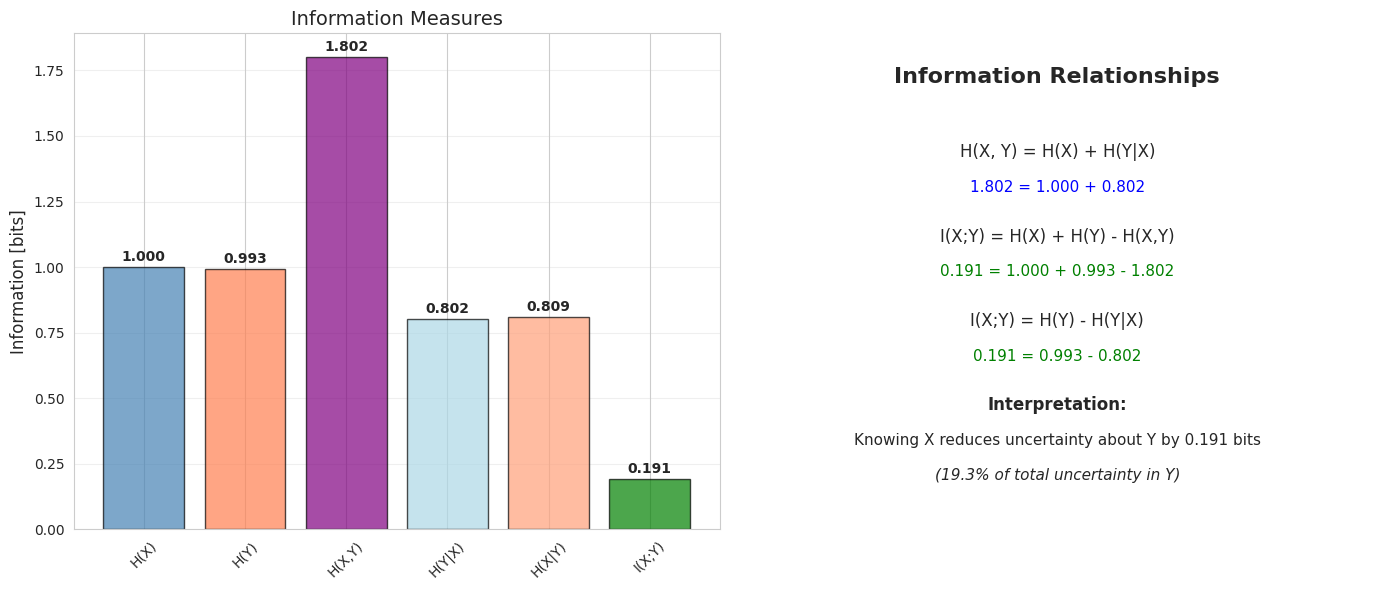


Mutual Information I(Weather; Activity) = 0.1912 bits
This means knowing the weather reduces uncertainty about activity by 0.1912 bits


In [13]:
# Use the weather-activity example.
print("Example: Weather and Activity Correlation")
utils.visualize_information_decomposition(joint_prob)

# Calculate and display mutual information.
mi = utils.calculate_mutual_information(joint_prob)
print(f"\nMutual Information I(Weather; Activity) = {mi:.4f} bits")
print(f"This means knowing the weather reduces uncertainty about activity by {mi:.4f} bits")

## Interactive Visualization: Correlation and Mutual Information

Adjust the correlation strength to see how it affects mutual information between two variables.

In [14]:
# Create interactive widget.
interact(utils.plot_mutual_info_interactive,
         correlation=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.5,
                                description='Correlation:', style={'description_width': 'initial'}));

interactive(children=(FloatSlider(value=0.5, description='Correlation:', max=1.0, step=0.05, style=SliderStyle…

<a name='kl-cross'></a>
# 4. KL Divergence and Cross-Entropy

## KL Divergence

**Kullback-Leibler (KL) Divergence** $D_{KL}(P \| Q)$ measures how one distribution differs from another:

$$D_{KL}(P \| Q) = \sum_x P(x) \log_2 \frac{P(x)}{Q(x)}$$

**Properties:**
- Not symmetric: $D_{KL}(P \| Q) \neq D_{KL}(Q \| P)$
- Non-negative: $D_{KL}(P \| Q) \geq 0$
- $D_{KL}(P \| Q) = 0$ if and only if $P = Q$
- Not a metric (no triangle inequality)

**Intuition:** Quantifies how much information is lost when $Q$ is used to approximate $P$

## Cross-Entropy

**Cross-entropy** $H(P, Q)$ measures the average number of bits needed to encode data from $P$ using code optimized for $Q$:

$$H(P, Q) = -\sum_x P(x) \log_2 Q(x)$$

**Relationship:**
$$H(P, Q) = H(P) + D_{KL}(P \| Q)$$

**Applications:**
- Loss function in classification (logistic regression, neural networks)
- Model evaluation and comparison
- Information compression

In [15]:
# Setup: Classification problem.
# True distribution (ground truth labels).
true_dist = np.array([0.0, 0.0, 1.0, 0.0])  # Class 2 is correct.
# Model predictions (different confidence levels).
model_confident = np.array([0.05, 0.05, 0.85, 0.05])  # Confident and correct.
model_uncertain = np.array([0.25, 0.25, 0.25, 0.25])  # Uncertain (uniform).
model_wrong = np.array([0.05, 0.85, 0.05, 0.05])     # Confident but wrong.
print("Classification Example")
print("=" * 60)
print("True label: Class 2")
print()

Classification Example
True label: Class 2



In [16]:
# Example 1: Confident and correct model prediction.
# Low cross-entropy and KL divergence indicate good match with true distribution.
model_pred = model_confident
name = "Confident & Correct"
kl = utils.calculate_kl_divergence(true_dist, model_pred)
ce = utils.calculate_cross_entropy(true_dist, model_pred)
h_true = utils.calculate_entropy(true_dist)
print(f"{name}:")
print(f"  Model prediction: {model_pred}")
print(f"  Cross-Entropy: {ce:.4f} bits")
print(f"  KL Divergence: {kl:.4f} bits")
print(f"  H(P) + D_KL(P||Q) = {h_true:.4f} + {kl:.4f} = {h_true + kl:.4f} (should equal CE)")

Confident & Correct:
  Model prediction: [0.05 0.05 0.85 0.05]
  Cross-Entropy: 0.2345 bits
  KL Divergence: 0.2345 bits
  H(P) + D_KL(P||Q) = -0.0000 + 0.2345 = 0.2345 (should equal CE)


In [17]:
# Example 2: Uncertain model prediction (uniform distribution).
# Higher cross-entropy due to uncertainty, even though it includes the correct class.
model_pred = model_uncertain
name = "Uncertain"
kl = utils.calculate_kl_divergence(true_dist, model_pred)
ce = utils.calculate_cross_entropy(true_dist, model_pred)
h_true = utils.calculate_entropy(true_dist)
print(f"{name}:")
print(f"  Model prediction: {model_pred}")
print(f"  Cross-Entropy: {ce:.4f} bits")
print(f"  KL Divergence: {kl:.4f} bits")
print(f"  H(P) + D_KL(P||Q) = {h_true:.4f} + {kl:.4f} = {h_true + kl:.4f} (should equal CE)")

Uncertain:
  Model prediction: [0.25 0.25 0.25 0.25]
  Cross-Entropy: 2.0000 bits
  KL Divergence: 2.0000 bits
  H(P) + D_KL(P||Q) = -0.0000 + 2.0000 = 2.0000 (should equal CE)


In [18]:
# Example 3: Confident but wrong model prediction.
# Very high cross-entropy and KL divergence due to confident wrong prediction.
model_pred = model_wrong
name = "Confident & Wrong"
kl = utils.calculate_kl_divergence(true_dist, model_pred)
ce = utils.calculate_cross_entropy(true_dist, model_pred)
h_true = utils.calculate_entropy(true_dist)
print(f"{name}:")
print(f"  Model prediction: {model_pred}")
print(f"  Cross-Entropy: {ce:.4f} bits")
print(f"  KL Divergence: {kl:.4f} bits")
print(f"  H(P) + D_KL(P||Q) = {h_true:.4f} + {kl:.4f} = {h_true + kl:.4f} (should equal CE)")

Confident & Wrong:
  Model prediction: [0.05 0.85 0.05 0.05]
  Cross-Entropy: 4.3219 bits
  KL Divergence: 4.3219 bits
  H(P) + D_KL(P||Q) = -0.0000 + 4.3219 = 4.3219 (should equal CE)


## Interactive Visualization: KL Divergence and Distribution Comparison

Adjust the parameters to see how KL divergence changes when approximating a distribution.

In [19]:
# Create interactive widget.
interact(utils.plot_kl_divergence_interactive,
         p1=FloatSlider(min=0.05, max=0.95, step=0.05, value=0.7,
                       description='P(outcome=1):', style={'description_width': 'initial'}),
         q1=FloatSlider(min=0.05, max=0.95, step=0.05, value=0.5,
                       description='Q(outcome=1):', style={'description_width': 'initial'}));

interactive(children=(FloatSlider(value=0.7, description='P(outcome=1):', max=0.95, min=0.05, step=0.05, style…

<a name='advanced'></a>
# 5. Advanced Topics

## Data Processing Inequality

**Statement:** Processing data cannot increase information, it can only lose information.

Formally, if $X \to Y \to Z$ forms a Markov chain, then:
$$I(X;Z) \leq I(X;Y)$$

**Intuition:** Information can only be lost through processing, never gained.

**Example:** If $X$ is a raw image and $Y$ is compressed version, no further processing $Z$ will recover more information about $X$ than $Y$ already contains.

## Maximum Entropy Principle

**Principle:** Use the distribution with the largest entropy given the constraints.

**Examples of maximum entropy distributions:**
- No constraints → Uniform distribution
- Positive mean constraint → Exponential distribution  
- Fixed variance → Normal distribution

## Minimum Description Length (MDL)

**Principle:** Select the model that minimizes total description length:

$$MDL(H) = L(H) + L(D | H)$$

where:
- $L(H)$ = length of the model/hypothesis
- $L(D|H)$ = length of data encoded using the model

**Intuition:** Balances model complexity with data fit (Occam's Razor principle)

## Kolmogorov Complexity

**Definition:** The length of the shortest program that outputs a string $x$.

**Examples:**
- String "00000000..." has low complexity (simple loop)
- Random string has high complexity (no pattern, no compression)

**Properties:**
- Not computable (theoretical concept)
- Related to MDL in practice
- Measures algorithmic randomness

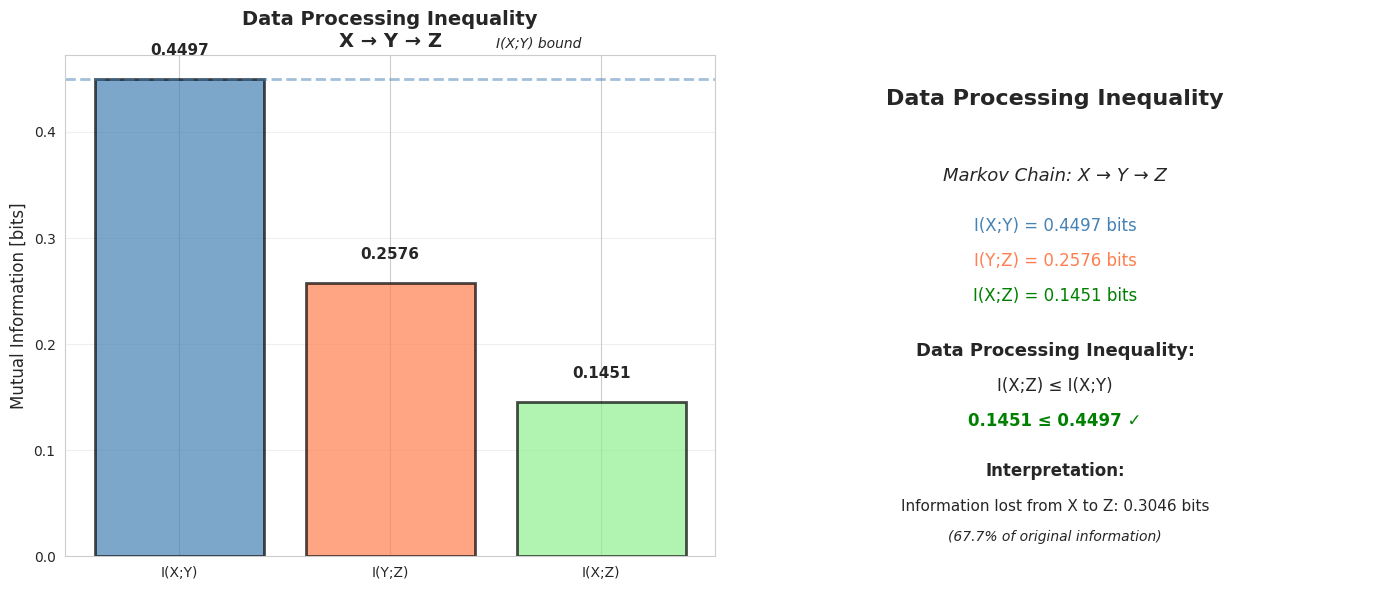

Data Processing Inequality Demonstration
Original signal X has 4 states
Compressed Y has 2 states
Processed Z has 2 states

I(X;Y) = 0.4497 bits (information between X and Y)
I(Y;Z) = 0.2576 bits (information between Y and Z)
I(X;Z) = 0.1451 bits (information between X and Z)

Data Processing Inequality: I(X;Z) ≤ I(X;Y)
0.1451 ≤ 0.4497: ✓ Satisfied

Information lost: 0.3046 bits (67.7%)


In [20]:
utils.demonstrate_data_processing_inequality()

# Summary and Key Takeaways

## Information Theory Relationships

The fundamental relationships in information theory:

1. **Entropy relationships:**
   - $H(X, Y) = H(X) + H(Y|X) = H(Y) + H(X|Y)$ (Chain Rule)
   - $H(X|Y) \leq H(X)$ with equality iff $X$ and $Y$ are independent

2. **Mutual information:**
   - $I(X;Y) = H(X) - H(X|Y) = H(Y) - H(Y|X)$
   - $I(X;Y) = H(X) + H(Y) - H(X,Y)$
   - $I(X;Y) \geq 0$ with equality iff $X$ and $Y$ are independent

3. **KL divergence and cross-entropy:**
   - $H(P,Q) = H(P) + D_{KL}(P \| Q)$
   - $D_{KL}(P \| Q) \geq 0$ with equality iff $P = Q$

4. **Data processing inequality:**
   - $I(X;Z) \leq I(X;Y)$ if $X \to Y \to Z$

## Applications in Machine Learning

- **Entropy:** Feature selection, decision tree splitting criteria
- **Mutual Information:** Dependency detection, feature relevance
- **Cross-Entropy:** Loss function for classification
- **KL Divergence:** Variational inference, model comparison
- **MDL:** Model selection, preventing overfitting

# Exercises

Try these exercises to deepen your understanding:

1. **Entropy Exercise:** Calculate the entropy of a 6-sided fair die. What happens if one outcome has probability 0.5 and the others share the remaining probability equally?

2. **Mutual Information Exercise:** Given the joint distribution in the weather-activity example, calculate $I(Weather; Activity)$ manually and verify it matches the computed value.

3. **Cross-Entropy Exercise:** For a 3-class classification problem, compute the cross-entropy loss when:
   - True label: class 1
   - Model prediction: [0.2, 0.6, 0.2]
   
4. **Data Processing Exercise:** Explain why JPEG compression is lossy in terms of the data processing inequality.

5. **Maximum Entropy Exercise:** Show that the uniform distribution maximizes entropy among all distributions with the same number of outcomes.

In [21]:
# Exercise workspace - use this cell to work on the exercises above.

# Exercise 1: Fair die entropy.
die_probs = np.array([1/6] * 6)
die_entropy = utils.calculate_entropy(die_probs)
print(f"Exercise 1: Fair die entropy = {die_entropy:.4f} bits")

# Your code here for other exercises...

Exercise 1: Fair die entropy = 2.5850 bits
